# Macchi-Wang Time Series

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR

from sklearn.ensemble import RandomForestRegressor

from itertools import product

from preprocessing.pipeline import preprocess_all
from preprocessing.visualization import plot_corr_matrix, plot_ccf_with_target

from models import (
    fit_rw_with_drift,
    expanding_window_forecast_rw_with_drift,
    fit_arima_model,
    forecast_arima_model,
    expanding_window_forecast_arima,
    align_lagged_with_train_test,
)

## Preprocessing

### Data Cleaning


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

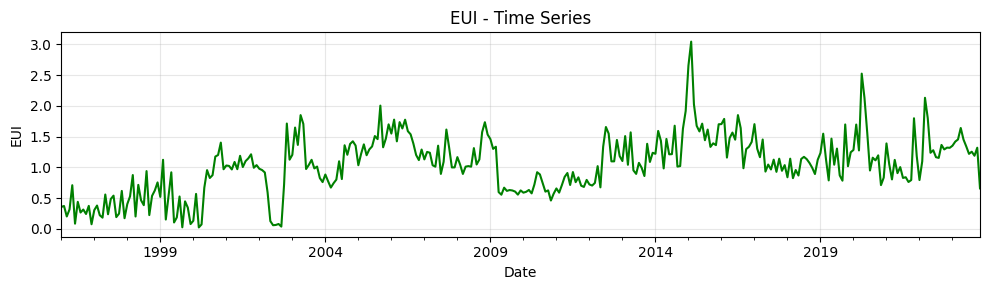

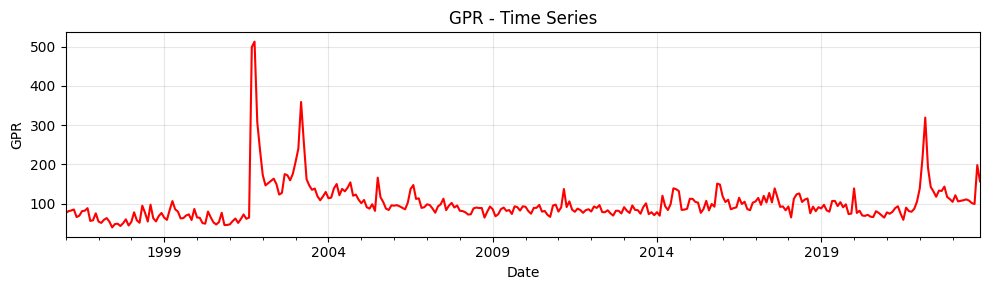

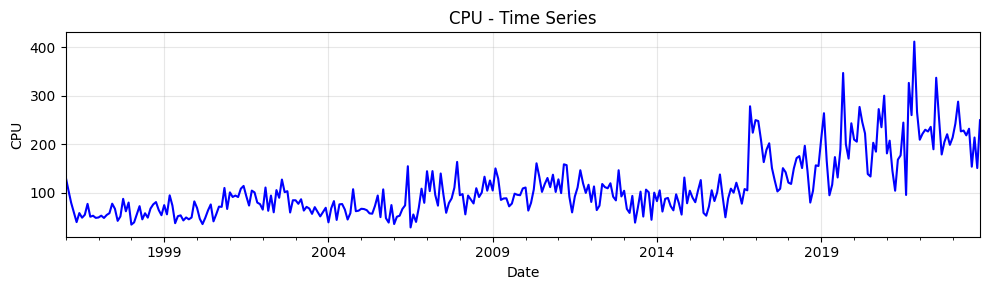

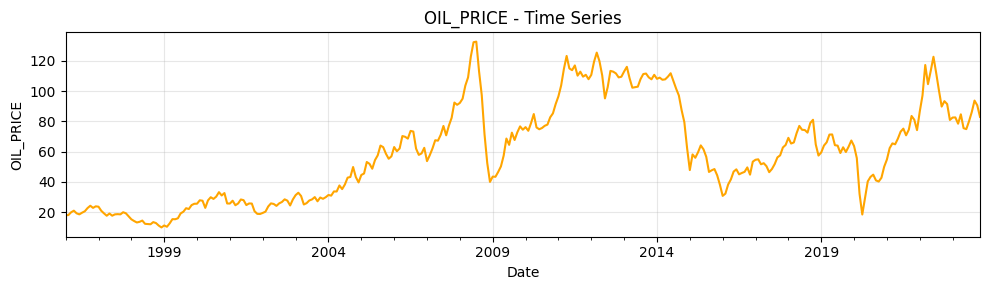

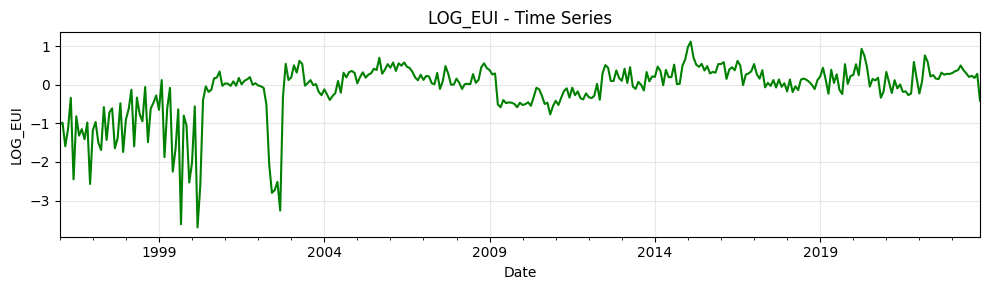

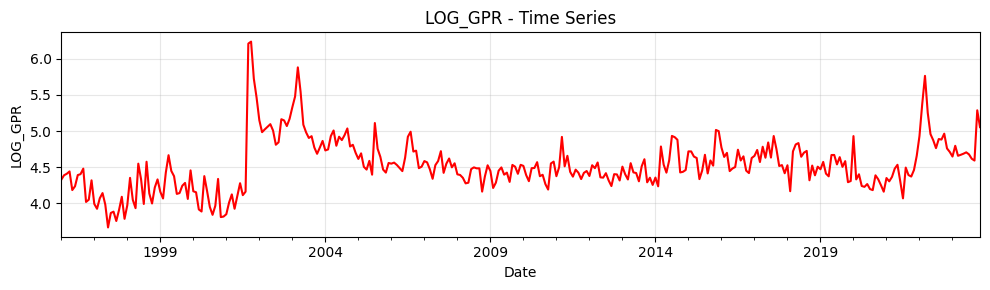

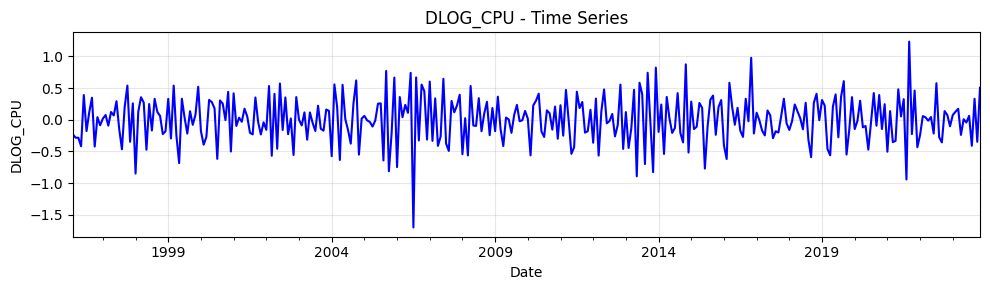

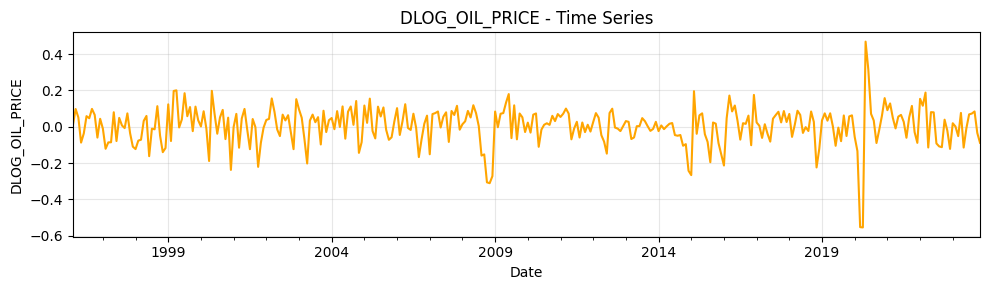

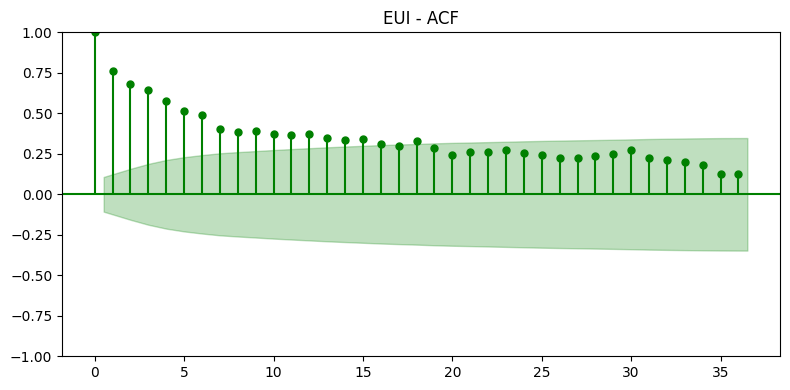

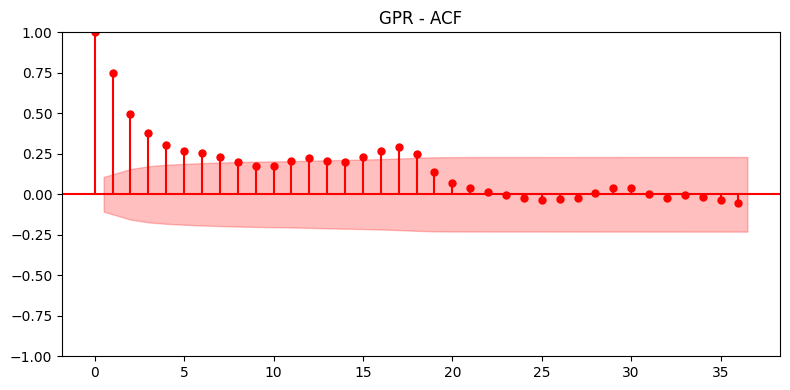

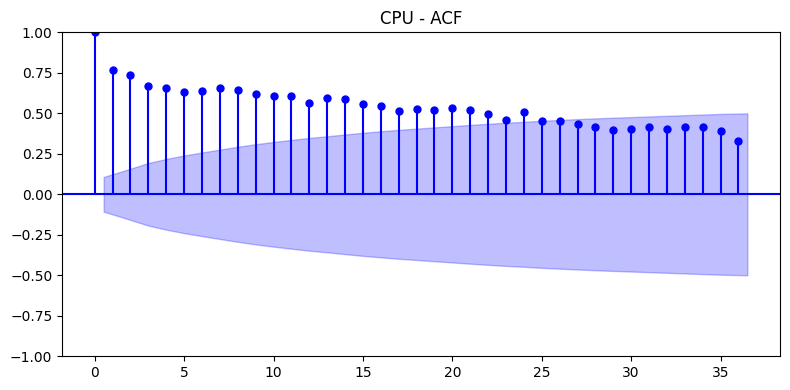

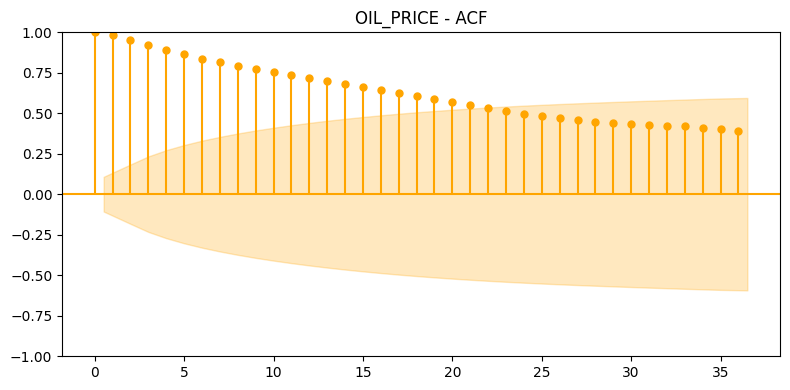

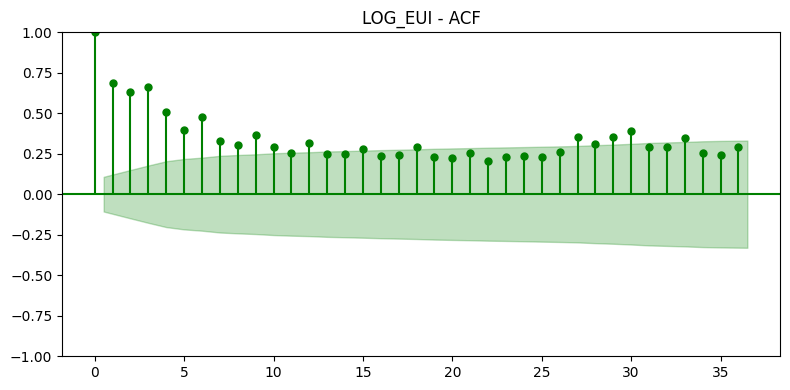

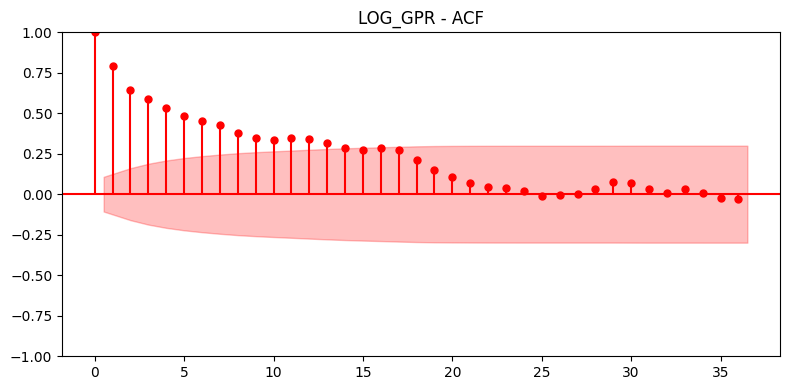

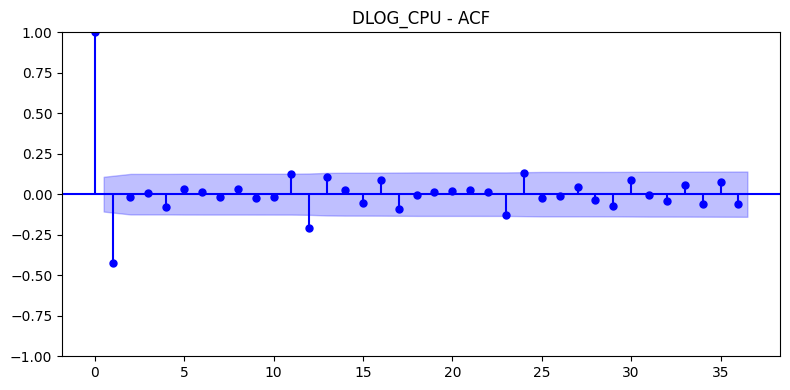

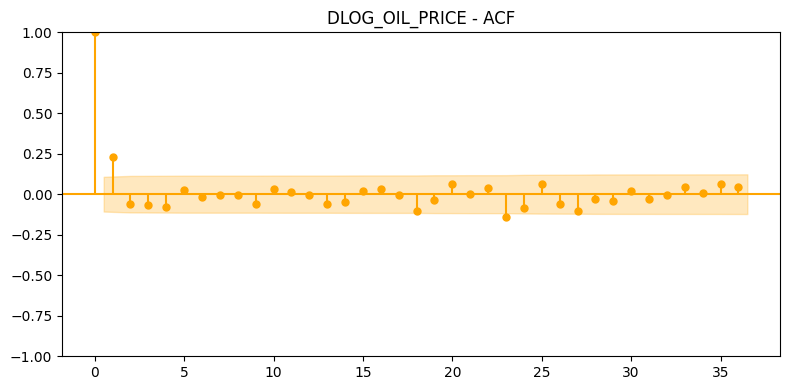

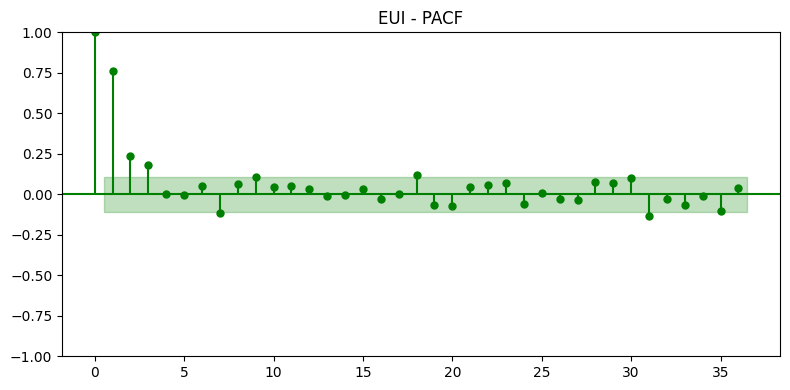

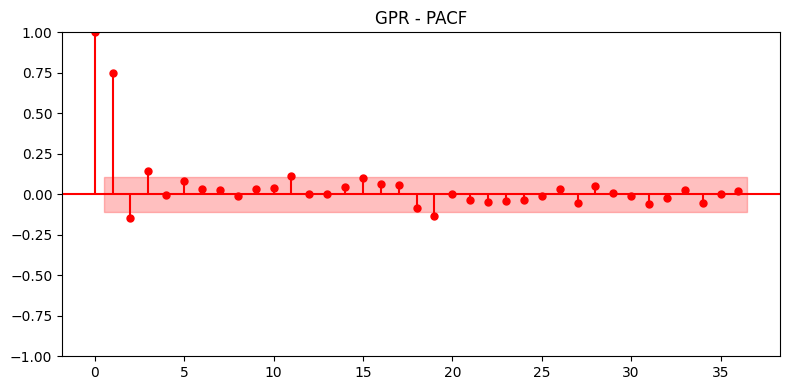

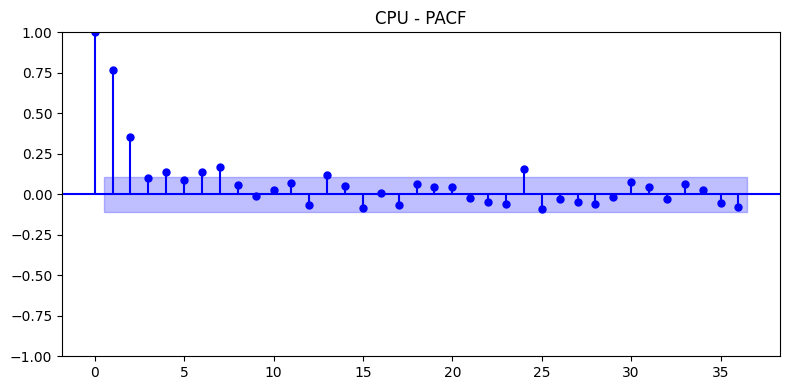

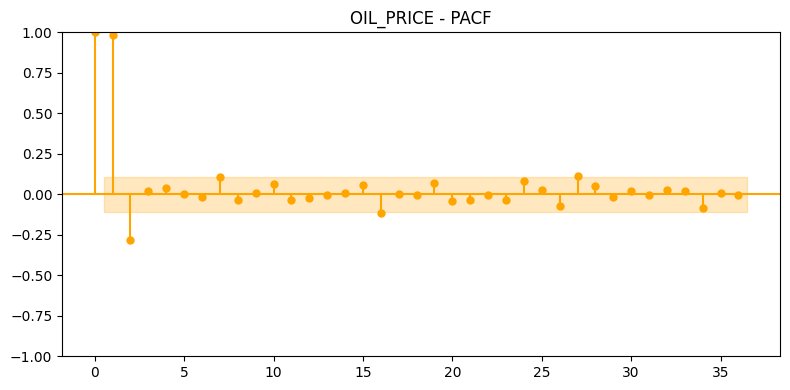

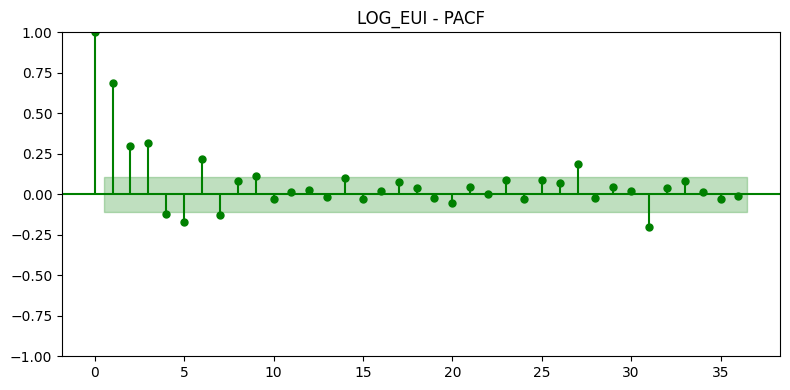

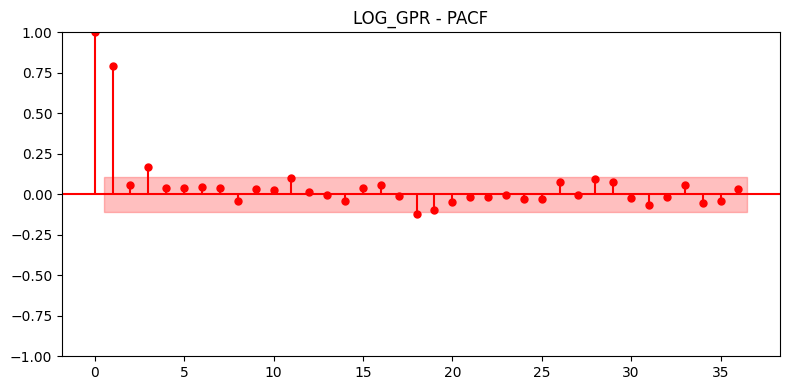

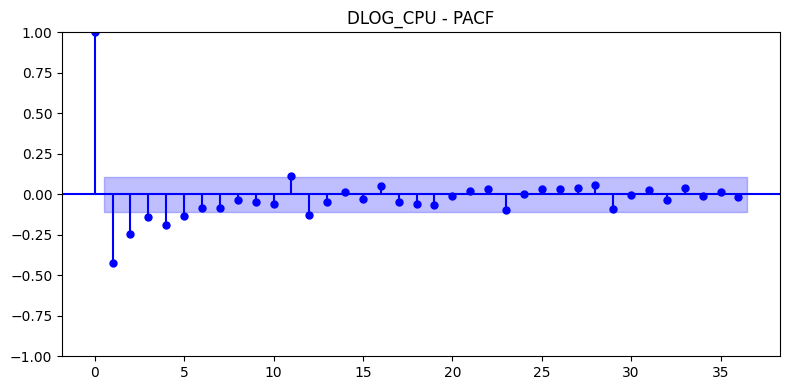

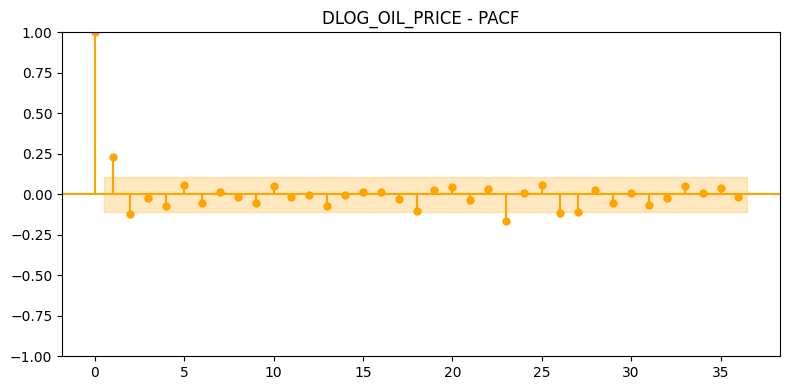

In [2]:
artifacts = preprocess_all(
    data_path="data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],   # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],         # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags= {"variables": ("eui", "gpr", "cpu", "oil_price", "log_eui", "log_gpr", "dlog_cpu", "dlog_oil_price",), "lags": 36, "time_series": True, "acf": True, "pacf": True, "pacf_method": "ywm",},
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]

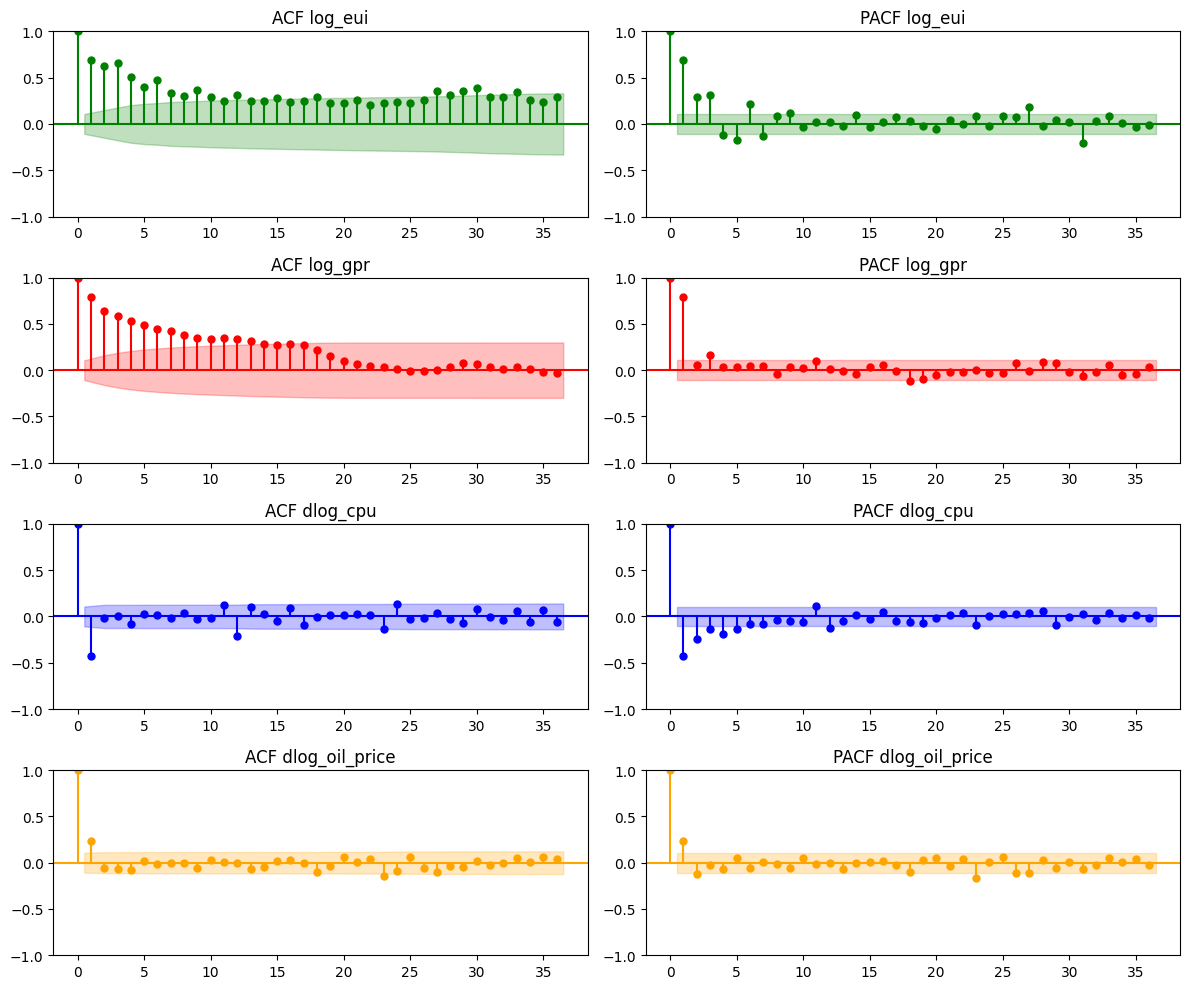

In [3]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# COLOR MAP (must match earlier definition)
COLOR_MAP = {
    "eui": "green",
    "gpr": "red",
    "cpu": "blue",
    "oil": "orange",
}

def get_color(var):
    if var.startswith("log_"):
        base = var.replace("log_", "")
    elif var.startswith("dlog_"):
        base = var.replace("dlog_", "")
    else:
        base = var
    if base == "oil_price":
        base = "oil"
    return COLOR_MAP.get(base, "black")


# Variables to compare (rows)
vars_to_compare = ["log_eui", "log_gpr", "dlog_cpu", "dlog_oil_price"]
lags = 36

# Ensure datetime index
ts_df = features_df.copy()
if "date" in ts_df.columns:
    ts_df = ts_df.set_index("date")

# Create 4 rows × 2 columns
fig, axes = plt.subplots(len(vars_to_compare), 2, figsize=(12, 10))
axes = axes.reshape(len(vars_to_compare), 2)

for i, var in enumerate(vars_to_compare):

    color = get_color(var)
    series = ts_df[var].dropna()

    # -------- ACF (left column) --------
    ax_acf = axes[i, 0]
    plot_acf(series, lags=lags, ax=ax_acf, color=color)
    ax_acf.set_title(f"ACF {var}")
    # force stems/lines to correct color
    for line in ax_acf.get_lines():
        line.set_color(color)
    for col in ax_acf.collections:
        try:
            col.set_color(color)
        except:
            pass

    # -------- PACF (right column) --------
    ax_pacf = axes[i, 1]
    plot_pacf(series, lags=lags, method="ywm", ax=ax_pacf, color=color)
    ax_pacf.set_title(f"PACF {var}")
    # force stems/lines to correct color
    for line in ax_pacf.get_lines():
        line.set_color(color)
    for col in ax_pacf.collections:
        try:
            col.set_color(color)
        except:
            pass

fig.tight_layout()
plt.show()


### Correlation

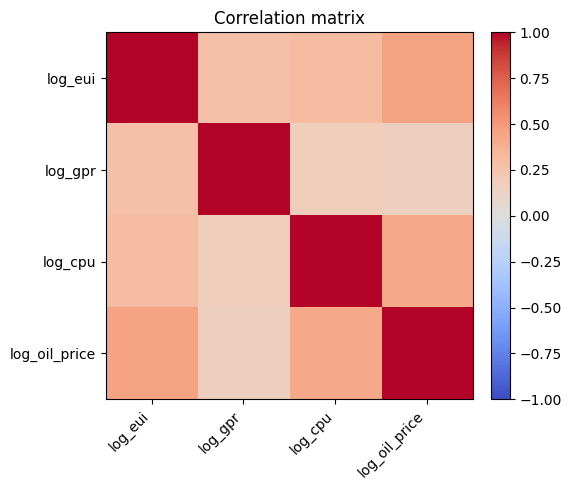

                log_eui   log_gpr   log_cpu  log_oil_price
log_eui        1.000000  0.277056  0.300055       0.449447
log_gpr        0.277056  1.000000  0.168410       0.155517
log_cpu        0.300055  0.168410  1.000000       0.414936
log_oil_price  0.449447  0.155517  0.414936       1.000000


In [4]:
corr_vars = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]
plot_corr_matrix(features_df, variables=corr_vars, date_col="date")

corr_matrix = features_df[corr_vars].corr()
print(corr_matrix)

# plot_ccf_with_target(features_df, target="log_eui", predictors=["dlog_cpu", "dlog_oil_price", "log_gpr"], date_col="date", max_lag=12,)


### TRAIN/TEST split

In [5]:
target_col = "log_eui"

### ADF Test

In [6]:
def adf_report(series: pd.Series, name: str, maxlag=None):
    s = series.dropna()
    res = adfuller(s, autolag="AIC" if maxlag is None else None, maxlag=maxlag)
    stat, pval, usedlag, nobs, crit, icbest = res
    print(f"\nADF test for {name}")
    print("---------------------------------")
    print(f"Test statistic: {stat:.4f}")
    print(f"p-value:        {pval:.4f}")
    print(f"Lags used:      {usedlag}")
    print(f"Observations:   {nobs}")
    print("Critical values:")
    for k, v in crit.items():
        print(f"  {k}: {v:.4f}")
    print(f"IC best:        {icbest:.4f}")


original_vars = ["eui", "gpr", "cpu", "oil_price"]
mod_vars = ["log_eui", "log_gpr", "dlog_cpu", "dlog_oil_price"]

print("=== ADF on original level variables ===")
for v in original_vars:
    if v in train_df.columns:
        adf_report(train_df[v], v)
    else:
        print(f"\n[skip] {v} not in train_df.columns")

print("\n=== ADF on dlog_ variables ===")
for v in mod_vars:
    if v in train_df.columns:
        adf_report(train_df[v], v)
    else:
        print(f"\n[skip] {v} not in train_df.columns")

=== ADF on original level variables ===

ADF test for eui
---------------------------------
Test statistic: -2.7765
p-value:        0.0617
Lags used:      8
Observations:   259
Critical values:
  1%: -3.4559
  5%: -2.8728
  10%: -2.5728
IC best:        70.3549

ADF test for gpr
---------------------------------
Test statistic: -5.2192
p-value:        0.0000
Lags used:      2
Observations:   265
Critical values:
  1%: -3.4553
  5%: -2.8725
  10%: -2.5726
IC best:        2495.5884

ADF test for cpu
---------------------------------
Test statistic: -2.9250
p-value:        0.0425
Lags used:      4
Observations:   263
Critical values:
  1%: -3.4555
  5%: -2.8726
  10%: -2.5727
IC best:        2392.0513

ADF test for oil_price
---------------------------------
Test statistic: -1.9751
p-value:        0.2976
Lags used:      1
Observations:   266
Critical values:
  1%: -3.4552
  5%: -2.8725
  10%: -2.5726
IC best:        1513.6239

=== ADF on dlog_ variables ===

ADF test for log_eui
----------

## Random Walk with Drift

In [7]:
# ---------------------------------------------------
# 1. Random Walk with Drift (on levels)
#    with 1-step ahead expanding-window forecasts
# ---------------------------------------------------
y_train_log = train_df[target_col]
y_test_log  = test_df[target_col]

# Fit once on the training sample (for in-sample residuals, etc.)
rw_fit = fit_rw_with_drift(y_train_log)

# Out-of-sample 1-step-ahead forecasts via expanding window
rw_fcast = expanding_window_forecast_rw_with_drift(
    y_train=y_train_log,
    y_test=y_test_log,
)

### Residuals

In [8]:
mu_rw = rw_fit["mu"]
y_train = y_train_log

# fitted(t) = y_{t-1} + mu
rw_fitted_in = y_train.shift(1) + mu_rw

rw_resid_in = (y_train - rw_fitted_in).dropna()
rw_resid_in.name = "rw_resid_in"

print("\nRW — in-sample residuals (head):")
print(rw_resid_in.head())


RW — in-sample residuals (head):
date
1996-02-01    0.037172
1996-03-01   -0.612036
1996-04-01    0.444506
1996-05-01    0.801428
1996-06-01   -2.115001
Name: rw_resid_in, dtype: float64


### Forecast

In [9]:
# Forecast errors (out-of-sample) per RW
rw_resid_oos = (y_test_log - rw_fcast).dropna()
rw_resid_oos.name = "rw_resid_oos"

print("\nRW — out-of-sample forecast errors:")
print(rw_resid_oos.head())


RW — out-of-sample forecast errors:
date
2018-05-01   -0.101613
2018-06-01    0.266094
2018-07-01    0.025731
2018-08-01   -0.036499
2018-09-01   -0.060217
Name: rw_resid_oos, dtype: float64


## ARIMA

### Best ARIMA

In [10]:
y_train_arima = train_df[target_col]
y_test_arima = test_df[target_col]

# Grid search for ARIMA(p,d,q)
orders_to_try = [
    (p, d, q)
    for p in range(0, 8)  # p = 0..5
    for d in range(0, 2)
    for q in range(0, 8)  # q = 0..5
]

seasonal_order = (0, 0, 0, 0)

arima_models = {}
arima_forecasts = {}
arima_errors = {}
arima_results = []

for order in orders_to_try:
    print(f"\n=== Fitting ARIMA{order} on {target_col} ===")
    try:
        res = fit_arima_model(
            y=y_train_arima,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
    except Exception as e:
        print(f"  FAILED for order {order}: {e}")
        continue

    arima_models[order] = res

    # Forecast on test set
    fcast = forecast_arima_model(
        res=res,
        steps=len(y_test_arima),
        index=y_test_arima.index,
    )
    arima_forecasts[order] = fcast

    # Forecast errors out-of-sample
    errors = (y_test_arima - fcast).dropna()
    arima_errors[order] = errors

    mse = float(np.mean(errors ** 2))
    rmse = float(np.sqrt(mse))

    # Residuals in-sample
    resid_in = res.resid.dropna()

    # Ljung–Box on in-sample residuals
    lb = acorr_ljungbox(resid_in, lags=[12, 24, 36], return_df=True)

    arima_results.append({
        "order": order,
        "aic": res.aic,
        "bic": res.bic,
        "rmse": rmse,
        "lb_pvalue_12": lb.loc[12, "lb_pvalue"],
        "lb_pvalue_24": lb.loc[24, "lb_pvalue"],
        "lb_pvalue_36": lb.loc[36, "lb_pvalue"],
    })

# Table summary
arima_df = pd.DataFrame(arima_results).sort_values(by="aic")
print("\n=== ARIMA model comparison (sorted by AIC) ===")
print(arima_df)

# Choose the best ARIMA (with lower RMSE)
best_order = tuple(arima_df.iloc[0]["order"])
print(f"\nBest ARIMA order: {best_order}")

arima_best_model = arima_models[best_order]


=== Fitting ARIMA(0, 0, 0) on log_eui ===

=== Fitting ARIMA(0, 0, 1) on log_eui ===

=== Fitting ARIMA(0, 0, 2) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


=== Fitting ARIMA(0, 0, 3) on log_eui ===

=== Fitting ARIMA(0, 0, 4) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


=== Fitting ARIMA(0, 0, 5) on log_eui ===

=== Fitting ARIMA(0, 0, 6) on log_eui ===


...

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred 


=== Fitting ARIMA(7, 1, 6) on log_eui ===

=== Fitting ARIMA(7, 1, 7) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



=== ARIMA model comparison (sorted by AIC) ===
         order         aic         bic      rmse   lb_pvalue_12  \
116  (7, 0, 4)  341.204643  387.543408  0.273032   5.852980e-01   
86   (5, 0, 6)  341.297852  387.636617  0.276451   9.037865e-01   
87   (5, 0, 7)  341.363413  391.212956  0.277557   9.170535e-01   
99   (6, 0, 3)  341.506082  380.757871  0.275725   8.574898e-01   
115  (7, 0, 3)  342.220627  384.994872  0.274499   8.778558e-01   
..         ...         ...         ...       ...            ...   
16   (1, 0, 0)  458.633093  469.394839  0.447358   2.666171e-26   
8    (0, 1, 0)  500.133621  503.717117  0.339799   5.355005e-38   
2    (0, 0, 2)  506.910760  521.229679  0.450654   4.477661e-42   
1    (0, 0, 1)  525.673827  536.424316  0.454171   2.435097e-54   
0    (0, 0, 0)  625.457244  632.631742  0.455905  5.367313e-136   

      lb_pvalue_24   lb_pvalue_36  
116   4.373660e-01   3.751237e-01  
86    7.542767e-01   4.979537e-01  
87    7.212444e-01   5.739995e-01  
99 

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Residuals

In [11]:
arima_best_resid_in = arima_best_model.resid.dropna()

arima_best_resid_in.name = "arima_best_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_best_resid_in.head())


Best ARIMA — in-sample residuals (head):
date
1996-01-01   -1.169122
1996-02-01   -1.326514
1996-03-01   -0.714399
1996-04-01    0.551719
1996-05-01    1.954862
Name: arima_best_resid_in, dtype: float64


#### Forecast

In [12]:
# Expanding-window 1-step-ahead forecasts on the test set
arima_best_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=best_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# Out-of-sample forecast errors (1-step-ahead, expanding window)
arima_best_errors_oos = (y_test_arima - arima_best_forecast).dropna()
arima_best_errors_oos.name = "arima_best_errors_oos"

rmse = float(np.sqrt(np.mean(arima_best_errors_oos**2)))
print("\nRMSE (1-step expanding window):", rmse)

print("\nBest ARIMA (expanding window) — out-of-sample forecast errors (head):")
print(arima_best_errors_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  


RMSE (1-step expanding window): 0.29375749313924265

Best ARIMA (expanding window) — out-of-sample forecast errors (head):
date
2018-05-01   -0.134757
2018-06-01    0.180118
2018-07-01    0.172439
2018-08-01   -0.082127
2018-09-01   -0.026696
Name: arima_best_errors_oos, dtype: float64


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### ARIMA (2,0,1)

In [13]:
# ===========================================
# Run ARIMA for ONE SET of PARAMETERS (p,d,q)
# ===========================================

# Choose the ARIMA order manually
order = (2, 0, 1)      # <-- put your numbers here, e.g. (2,1,0)
seasonal_order = (0, 0, 0, 0)

print(f"\n=== Fitting ARIMA{order} on {target_col} ===")

# ---- Fit model ----
res = fit_arima_model(
    y=y_train_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# ---- Forecast on test set ----
fcast = forecast_arima_model(
    res=res,
    steps=len(y_test_arima),
    index=y_test_arima.index,
)

# ---- Forecast errors ----
errors = (y_test_arima - fcast).dropna()
mse = float(np.mean(errors ** 2))
rmse = float(np.sqrt(mse))

# ---- Residual diagnostics ----
resid_in = res.resid.dropna()
lb = acorr_ljungbox(resid_in, lags=[12, 24], return_df=True)

print("\n=== RESULTS ===")
print(f"AIC:  {res.aic}")
print(f"BIC:  {res.bic}")
print(f"RMSE: {rmse}")
print("\nLjung–Box p-values:")
print(lb)

# Optional: store outputs
arima_201_model = res
arima_201_forecast = fcast


=== Fitting ARIMA(2, 0, 1) on log_eui ===

=== RESULTS ===
AIC:  422.7156676945791
BIC:  440.6331492384876
RMSE: 0.41277306416588766

Ljung–Box p-values:
       lb_stat     lb_pvalue
12   90.508170  3.936286e-14
24  108.689177  9.546153e-13


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Residuals

In [14]:
arima_201_resid_in = arima_201_model.resid.dropna()

arima_201_resid_in.name = "arima_201_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_201_resid_in.head())


Best ARIMA — in-sample residuals (head):
date
1996-01-01   -0.867753
1996-02-01   -0.131574
1996-03-01   -0.687801
1996-04-01    0.002753
1996-05-01    0.750437
Name: arima_201_resid_in, dtype: float64


#### Forecasts

In [15]:
# ===========================================
# 1-step-ahead EXPANDING-WINDOW forecasts
# ===========================================

print("\n=== 1-step-ahead expanding-window forecasts on TEST sample ===")

arima_201_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=(2, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# ---- OOS errors ----
arima_201_errors_oos = (y_test_arima - arima_201_forecast).dropna()
arima_201_errors_oos.name = "arima_201_errors_oos"

rmse = float(np.sqrt(np.mean(arima_201_errors_oos**2)))
print("\nRMSE (1-step expanding window):", rmse)

print("\nHEAD of 1-step expanding-window forecast errors:")
print(arima_201_errors_oos.head())



=== 1-step-ahead expanding-window forecasts on TEST sample ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


RMSE (1-step expanding window): 0.2710188867275635

HEAD of 1-step expanding-window forecast errors:
date
2018-05-01   -0.054371
2018-06-01    0.239644
2018-07-01    0.182712
2018-08-01    0.076472
2018-09-01   -0.000189
Name: arima_201_errors_oos, dtype: float64


## VAR

### VAR - Best

In [16]:
# ⚠️ CHANGE: Now using all log level variables
var_endog_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

# TRAIN and TEST endogenous matrices
endog_train_var = train_df[var_endog_cols].dropna()
endog_test_var  = test_df[var_endog_cols]

# Combined full sample (needed for expanding window)
endog_full = pd.concat([train_df[var_endog_cols], test_df[var_endog_cols]])

# -----------------------------
# 2. Lag order selection (AIC) on TRAIN sample only
# -----------------------------
max_lags_var = 12  # adjustable
lag_order_res = VAR(endog_train_var).select_order(maxlags=max_lags_var)
print(lag_order_res.summary())
best_lag_var = lag_order_res.selected_orders["aic"]
print(f"\nBest VAR lag (AIC): {best_lag_var}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -5.596      -5.541    0.003712      -5.574
1       -11.19     -10.92*   1.376e-05      -11.08
2       -11.27      -10.77   1.272e-05      -11.07
3       -11.42      -10.70   1.100e-05     -11.13*
4       -11.38      -10.44   1.143e-05      -11.00
5       -11.43      -10.27   1.090e-05      -10.96
6       -11.42      -10.03   1.102e-05      -10.86
7      -11.43*      -9.827  1.087e-05*      -10.79
8       -11.37      -9.541   1.162e-05      -10.63
9       -11.30      -9.251   1.247e-05      -10.48
10      -11.27      -9.004   1.283e-05      -10.36
11      -11.30      -8.803   1.261e-05      -10.29
12      -11.35      -8.639   1.196e-05      -10.26
--------------------------------------------------

Best VAR lag (AIC): 7


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Residuals

In [17]:

# -----------------------------
# 3. Fit VAR on entire TRAIN sample (no dummies)
# -----------------------------
var_model_train = VAR(endog_train_var)
var_res_train = var_model_train.fit(best_lag_var)
print(var_res_train.summary())

# ⚠️ CHANGE: Now extracting "log_eui" (level, not difference)
# In-sample fitted log_eui
var_fitted_log = var_res_train.fittedvalues["log_eui"]

# ⚠️ CHANGE: In-sample residuals in LOG LEVEL space
actual_log_train = endog_train_var.loc[var_fitted_log.index, "log_eui"]
var_resid_in = (actual_log_train - var_fitted_log).dropna()
var_resid_in.name = "var_resid_in"
print("\nVAR — in-sample residuals (log level, head):")
print(var_resid_in.head())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 05, Dec, 2025
Time:                     15:20:29
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -9.86368
Nobs:                     261.000    HQIC:                  -10.8111
Log likelihood:           128.580    FPE:                1.07112e-05
AIC:                     -11.4479    Det(Omega_mle):     7.02759e-06
--------------------------------------------------------------------
Results for equation log_eui
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -0.900478         0.617454           -1.458           0.145
L1.log_eui               0.461015         0.064695            7.126           0.000
L1.log_gpr               0.210833         0.12

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Forecast

In [18]:
# -----------------------------
# 4. Expanding-window 1-step-ahead forecasts (no exog)
# -----------------------------
test_index = test_df.index
n_train = len(train_df)
var_log_eui_fcast = []

for i, current_date in enumerate(test_index):
    # Up to t-1 in full sample
    end_train_idx = n_train + i
    endog_train_i = endog_full.iloc[:end_train_idx].dropna()

    # Fit VAR for this window
    var_model_i = VAR(endog_train_i)
    var_res_i = var_model_i.fit(best_lag_var)

    # last best_lag_var observations
    y_history = endog_train_i.values[-best_lag_var:]

    # 1-step-ahead forecast (NO exog)
    fcast_i = var_res_i.forecast(y=y_history, steps=1)

    # ⚠️ CHANGE: extract log_eui forecast (level)
    log_eui_idx = endog_train_i.columns.get_loc("log_eui")
    log_eui_hat = fcast_i[0, log_eui_idx]
    var_log_eui_fcast.append(log_eui_hat)

# ⚠️ OUTPUT NAME: var_log_eui_forecast (directly forecasted levels)
var_log_eui_forecast = pd.Series(
    var_log_eui_fcast,
    index=test_index,
    name="var_log_eui_forecast"
)
print("\nVAR — 1-step-ahead forecasts (log_eui level, head):")
print(var_log_eui_forecast.head())

# -----------------------------
# 5. Out-of-sample forecast errors (in log space)
# -----------------------------
# Actual log(EUI) in test set
actual_log_eui_test = test_df.loc[test_index, "log_eui"]

# Forecast errors in log space
var_resid_oos = (actual_log_eui_test - var_log_eui_forecast).dropna()
var_resid_oos.name = "var_resid_oos"
print("\nVAR — out-of-sample forecast errors (log space, head):")
print(var_resid_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


VAR — 1-step-ahead forecasts (log_eui level, head):
date
2018-05-01    0.183106
2018-06-01   -0.271343
2018-07-01   -0.090424
2018-08-01    0.268531
2018-09-01    0.282341
Name: var_log_eui_forecast, dtype: float64

VAR — out-of-sample forecast errors (log space, head):
date
2018-05-01   -0.323566
2018-06-01    0.400283
2018-07-01    0.249391
2018-08-01   -0.141672
2018-09-01   -0.211443
Name: var_resid_oos, dtype: float64


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b

### VAR - Manual Choice

In [19]:
# -----------------------------
# VAR(p = 2) - Manual choice
# -----------------------------

# Endogenous variables in LOG LEVELS (same as in VAR - Best)
var_endog_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

# TRAIN and TEST endogenous matrices
endog_train_var = train_df[var_endog_cols].dropna()
endog_test_var  = test_df[var_endog_cols]

# Combined full sample (needed for expanding window)
endog_full = pd.concat([train_df[var_endog_cols], test_df[var_endog_cols]])

# -----------------------------
# 1. Set manual lag order
# -----------------------------
manual_lag_var = 2
print(f"Manual VAR lag order p = {manual_lag_var}")

# -----------------------------
# 2. Fit VAR(p=2) on entire TRAIN sample
# -----------------------------
var_p2_model_train = VAR(endog_train_var)
var_p2_res_train   = var_p2_model_train.fit(manual_lag_var)
print(var_p2_res_train.summary())

Manual VAR lag order p = 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 05, Dec, 2025
Time:                     15:20:30
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -10.7759
Nobs:                     266.000    HQIC:                  -11.0661
Log likelihood:           23.9521    FPE:                1.28673e-05
AIC:                     -11.2609    Det(Omega_mle):     1.12638e-05
--------------------------------------------------------------------
Results for equation log_eui
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -1.574810         0.609967           -2.582           0.010
L1.log_eui               0.418378         0.060513            6.914           0.000
L1.log_gpr         

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Residuals

In [20]:
# In-sample fitted log_eui
var_p2_fitted_log = var_p2_res_train.fittedvalues["log_eui"]

# In-sample residuals in log-level space
actual_log_train = endog_train_var.loc[var_p2_fitted_log.index, "log_eui"]
var_p2_resid_in  = (actual_log_train - var_p2_fitted_log).dropna()
var_p2_resid_in.name = "var_p2_resid_in"

print("\nVAR(p=2) — in-sample residuals (log space, head):")
print(var_p2_resid_in.head())


VAR(p=2) — in-sample residuals (log space, head):
date
1996-03-01   -0.694873
1996-04-01    0.040702
1996-05-01    0.806072
1996-06-01   -1.690263
1996-07-01    0.506826
Name: var_p2_resid_in, dtype: float64


#### Forecast

In [21]:
# -----------------------------
# 3. Expanding-window 1-step-ahead forecasts with VAR(p=2)
# -----------------------------
test_index = test_df.index
n_train    = len(train_df)
var_p2_log_eui_fcast = []

for i, current_date in enumerate(test_index):
    # Window up to t-1 in the full sample
    end_train_idx = n_train + i
    endog_train_i = endog_full.iloc[:end_train_idx].dropna()

    # Fit VAR(p=2) on this window
    var_p2_model_i = VAR(endog_train_i)
    var_p2_res_i   = var_p2_model_i.fit(manual_lag_var)

    # Last p observations as starting history
    y_history = endog_train_i.values[-manual_lag_var:]

    # 1-step-ahead forecast (no exogenous variables)
    fcast_i = var_p2_res_i.forecast(y=y_history, steps=1)

    # Extract log_eui forecast (log-level)
    log_eui_idx = endog_train_i.columns.get_loc("log_eui")
    log_eui_hat = fcast_i[0, log_eui_idx]
    var_p2_log_eui_fcast.append(log_eui_hat)

# Convert to Series aligned with TEST index
var_p2_log_eui_forecast = pd.Series(
    var_p2_log_eui_fcast,
    index=test_index,
    name="var_p2_log_eui_forecast",
)

print("\nVAR(p=2) — 1-step-ahead forecasts (log_eui level, head):")
print(var_p2_log_eui_forecast.head())

# -----------------------------
# 4. Out-of-sample forecast errors (log space)
# -----------------------------
actual_log_eui_test = test_df.loc[test_index, "log_eui"]
var_p2_resid_oos = (actual_log_eui_test - var_p2_log_eui_forecast).dropna()
var_p2_resid_oos.name = "var_p2_resid_oos"

print("\nVAR(p=2) — out-of-sample forecast errors (log space, head):")
print(var_p2_resid_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


VAR(p=2) — 1-step-ahead forecasts (log_eui level, head):
date
2018-05-01    0.031923
2018-06-01    0.031072
2018-07-01    0.083297
2018-08-01    0.240623
2018-09-01    0.155608
Name: var_p2_log_eui_forecast, dtype: float64

VAR(p=2) — out-of-sample forecast errors (log space, head):
date
2018-05-01   -0.172383
2018-06-01    0.097868
2018-07-01    0.075669
2018-08-01   -0.113764
2018-09-01   -0.084709
Name: var_p2_resid_oos, dtype: float64


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Random Forest

In [68]:
# ---------------------------------------------------
# 1. Create RF lagged-feature dataset
# ---------------------------------------------------

rf_feature_cols = [
    "log_gpr", "log_cpu", "log_oil_price",
    "COVID_WINDOW_2020_03_11_2023_05_05",
    "RU_UA_WAR_PULSE_2022_02_24",
    "FUKUSHIMA_PULSE_2011_03_11",
    "GFC_WINDOW_2007_12_01_2009_06_30",
    "PARIS_COP21_PULSE_2015_12_12",
    "SEP11_PULSE_2001_09_11",
]

X_train_rf, y_train_rf, X_test_rf, y_test_rf = align_lagged_with_train_test(
    features_df=features_df,
    train_df=train_df,
    test_df=test_df,
    target_col=target_col,
    feature_cols=rf_feature_cols,
    max_lag=3,
    date_col="date",
)

print("Shapes:")
print("X_train_rf:", X_train_rf.shape)
print("y_train_rf:", y_train_rf.shape)
print("X_test_rf:", X_test_rf.shape)
print("y_test_rf:", y_test_rf.shape)

# ---------------------------------------------------
# 2. Define RF param_grid as dict of lists
# ---------------------------------------------------

param_grid = {"n_estimators": [200, 300, 500], "max_depth": [3, 4, 5], "min_samples_leaf": [1, 2, 4],}

# From the grid above the best params are:

# === RF Time-series CV results (sorted by MSFE) ===
#     n_estimators  max_depth  min_samples_leaf   cv_msfe
# 24           500          5                 1  0.053973
# 15           300          5                 1  0.054652
# 21           500          4                 1  0.054652
# 25           500          5                 2  0.054810
# 3            200          4                 1  0.055036

# Best RF params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}


#For computational efficiency, we simply use the best params found above.

param_grid = {"n_estimators": [500], "max_depth": [5], "min_samples_leaf": [1],}

# ---------------------------------------------------
# 3. Time-series CV scoring for one param combination
# ---------------------------------------------------

def ts_cv_score_rf(
        X, y,
        params,
        initial_train_size,
        h=1,
        step=1,
        random_state=6,
):
    """
    Expanding-window CV for RF.
    Returns mean MSFE (mean squared forecast error).
    """
    n = len(y)
    msfes = []

    train_start = 0
    train_end = initial_train_size

    while True:
        test_start = train_end
        test_end = test_start + h

        if test_end > n:
            break

        X_train_cv = X.iloc[train_start:train_end]
        y_train_cv = y.iloc[train_start:train_end]
        X_test_cv = X.iloc[test_start:test_end]
        y_test_cv = y.iloc[test_start:test_end]

        rf = RandomForestRegressor(
            random_state=random_state,
            n_jobs=-1,
            **params,
        )
        rf.fit(X_train_cv, y_train_cv)
        y_pred_cv = rf.predict(X_test_cv)

        msfe = np.mean((y_test_cv.values - y_pred_cv) ** 2)
        msfes.append(msfe)

        train_end += step  # expand window

    return np.mean(msfes) if msfes else np.inf


# ---------------------------------------------------
# 4. Loop over all combinations of the param_grid
# ---------------------------------------------------

keys = list(param_grid.keys())
values_product = list(product(*param_grid.values()))

cv_results = []
initial_train_size = int(len(y_train_rf) * 0.5)

print("\nStarting RF Grid Search...\n")

for vals in values_product:
    params = dict(zip(keys, vals))
    print("Testing:", params)

    msfe_cv = ts_cv_score_rf(
        X=X_train_rf,
        y=y_train_rf,
        params=params,
        initial_train_size=initial_train_size,
        h=1,
        step=1,
        random_state=6,
    )

    cv_results.append({**params, "cv_msfe": msfe_cv})

cv_results_df = pd.DataFrame(cv_results).sort_values(by="cv_msfe")
print("\n=== RF Time-series CV results (sorted by MSFE) ===")
print(cv_results_df.head())

# ---------------------------------------------------
# 5. Select best parameters
# ---------------------------------------------------

best = cv_results_df.iloc[0]
best_params = {
    "n_estimators": int(best["n_estimators"]),
    "max_depth": int(best["max_depth"]),
    "min_samples_leaf": int(best["min_samples_leaf"]),
}

print("\nBest RF params:", best_params)

# ---------------------------------------------------
# 6. Fit final RF on full training set & forecast test
# ---------------------------------------------------

rf_best = RandomForestRegressor(
    n_jobs=-1,
    random_state=6,
    **best_params,
)

rf_best.fit(X_train_rf, y_train_rf)

rf_fcast = rf_best.predict(X_test_rf)
rf_fcast_series = pd.Series(rf_fcast, index=X_test_rf.index, name="rf_forecast")

print("\nRandom Forest final forecast (head):")
print(rf_fcast_series.head())

# ---------------------------------------------------
# 7. Basic metric: RF feature importances
# ---------------------------------------------------

# Extract feature importances
importances = rf_best.feature_importances_

# Build a dataframe
feat_imp_df = (
    pd.DataFrame({
        "feature": X_train_rf.columns,
        "importance": importances
    })
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Random Forest Feature Importances (MDI) ===")
print(feat_imp_df.head(20))  # show top 20


Shapes:
X_train_rf: (265, 30)
y_train_rf: (265,)
X_test_rf: (67, 30)
y_test_rf: (67,)

Starting RF Grid Search...

Testing: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

=== RF Time-series CV results (sorted by MSFE) ===
   n_estimators  max_depth  min_samples_leaf   cv_msfe
0           500          5                 1  0.053235

Best RF params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

Random Forest final forecast (head):
date
2018-05-01   -0.105470
2018-06-01   -0.139654
2018-07-01    0.003386
2018-08-01    0.138245
2018-09-01    0.135561
Name: rf_forecast, dtype: float64

=== Random Forest Feature Importances (MDI) ===
                                  feature    importance
0                            log_eui_lag2  2.732796e-01
1                            log_eui_lag1  1.930007e-01
2                      log_oil_price_lag3  1.658678e-01
3                            log_eui_lag3  1.403025e-01
4                            log_gpr_lag3  6.441337e-0

### Residuals

In [69]:
# Fitted values sul training per RF
rf_fitted_in = rf_best.predict(X_train_rf)
rf_fitted_in = pd.Series(rf_fitted_in, index=X_train_rf.index, name="rf_fitted_in")

# Residui in-sample RF
rf_resid_in = (y_train_rf - rf_fitted_in).dropna()
rf_resid_in.name = "rf_resid_in"

print("\nRF — in-sample residuals:")
print(rf_resid_in.head())


RF — in-sample residuals:
date
1996-04-01   -0.227914
1996-05-01    0.543515
1996-06-01   -0.651148
1996-07-01    0.140386
1996-08-01   -0.340267
Name: rf_resid_in, dtype: float64


### Forecast

In [70]:
# Forecast errors (out-of-sample) RF
rf_resid_oos = (y_test_rf - rf_fcast_series).dropna()
rf_resid_oos.name = "rf_resid_oos"

print("\nRF — out-of-sample forecast errors:")
print(rf_resid_oos.head())


RF — out-of-sample forecast errors:
date
2018-05-01   -0.034990
2018-06-01    0.268594
2018-07-01    0.155581
2018-08-01   -0.011386
2018-09-01   -0.064663
Name: rf_resid_oos, dtype: float64


## Final Results

### Confront the residuals


Random Walk with Drift (in-sample, level)
------------------------------
Mean:   0.000000
Std:    0.617172
Min:    -3.137274
Max:    2.930597

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
1    46.129237  1.107040e-11
2    52.104285  4.849514e-12
3    79.227046  4.495974e-17
12  224.326707  3.004466e-41
24  260.351341  1.452476e-41
48  419.843145  7.536207e-61


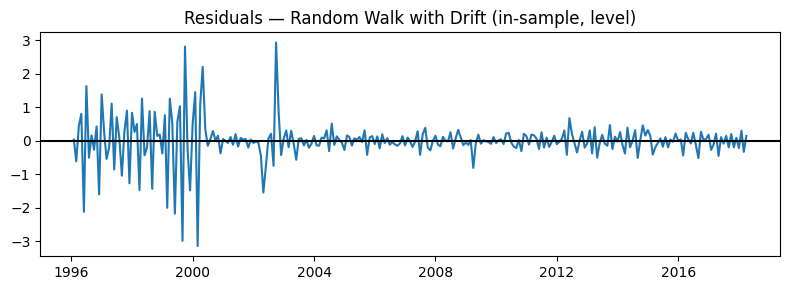

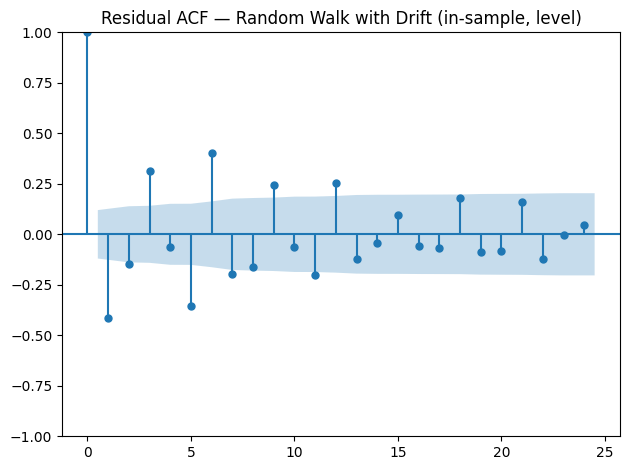

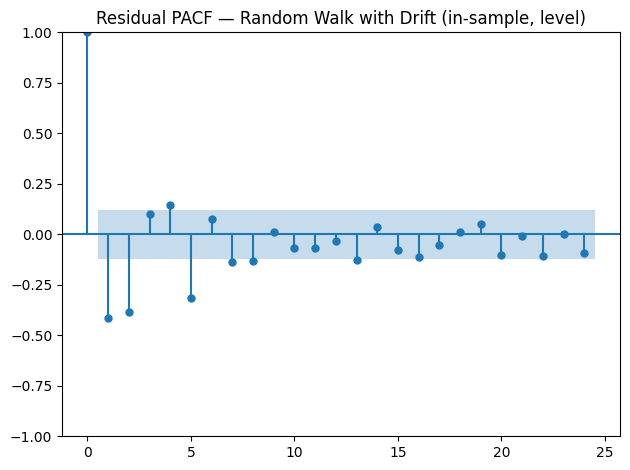


Best ARIMA(7, 0, 4) (in-sample, level)
------------------------------
Mean:   -0.004962
Std:    0.527440
Min:    -2.636539
Max:    2.079685

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
1     0.016396  8.981126e-01
2     0.904905  6.360663e-01
3    22.579928  4.939987e-05
12   90.508170  3.936286e-14
24  108.689177  9.546153e-13
48  206.604757  1.433087e-21


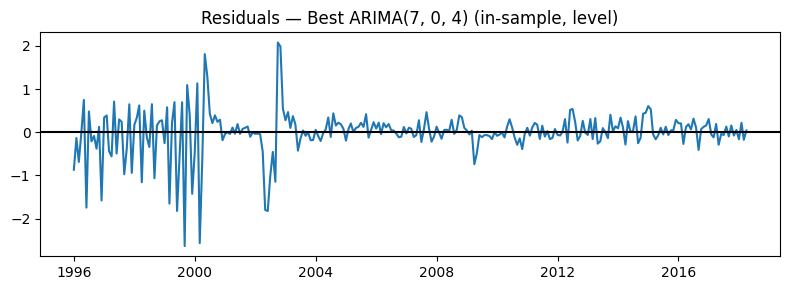

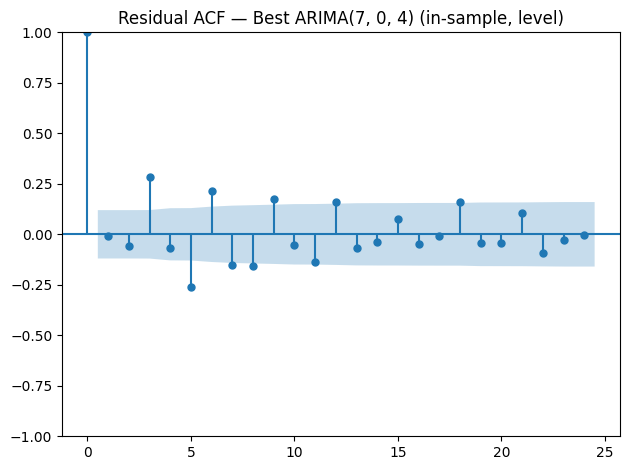

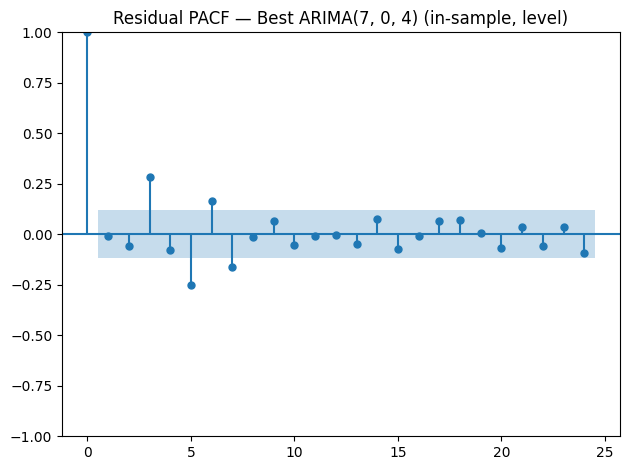


ARIMA(2, 0, 1) (in-sample, level)
------------------------------
Mean:   -0.004962
Std:    0.527440
Min:    -2.636539
Max:    2.079685

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
1     0.016396  8.981126e-01
2     0.904905  6.360663e-01
3    22.579928  4.939987e-05
12   90.508170  3.936286e-14
24  108.689177  9.546153e-13
48  206.604757  1.433087e-21


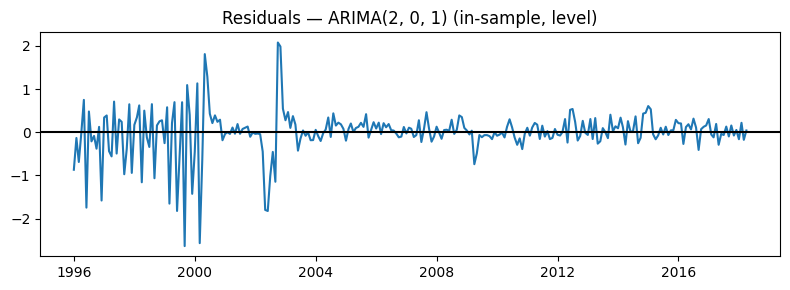

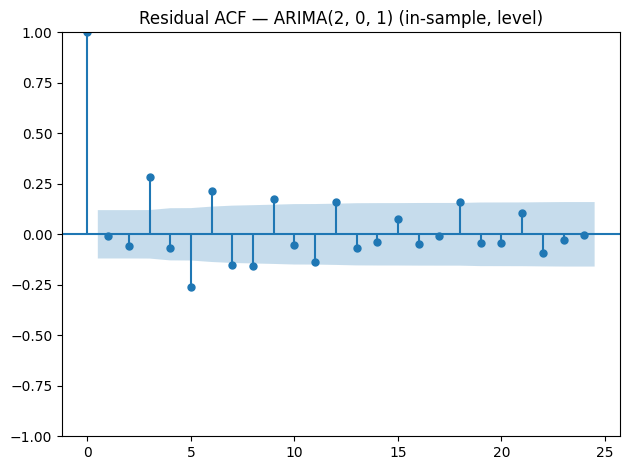

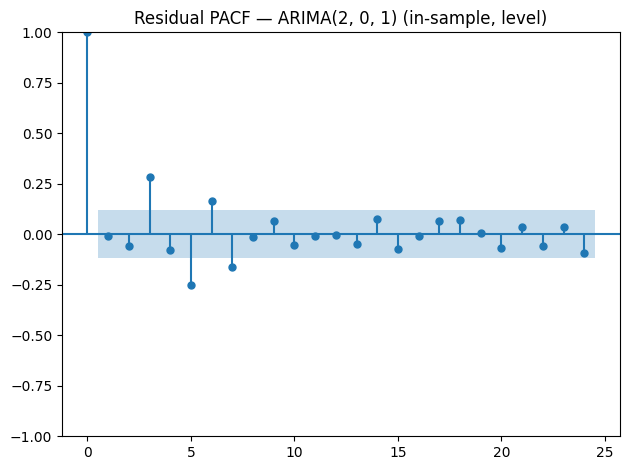


VAR (in-sample, level)
------------------------------
Mean:   -0.000000
Std:    0.421826
Min:    -1.492449
Max:    1.663157

Ljung–Box test (H0: no autocorrelation)
      lb_stat  lb_pvalue
1    0.065844   0.797487
2    0.090929   0.955553
3    0.324722   0.955314
12   6.774103   0.872174
24  19.872981   0.703976
48  51.452845   0.340168


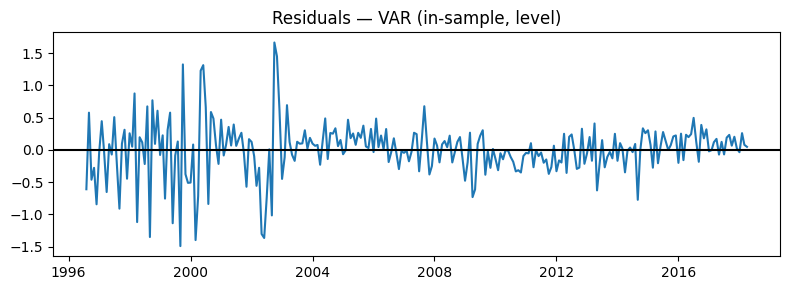

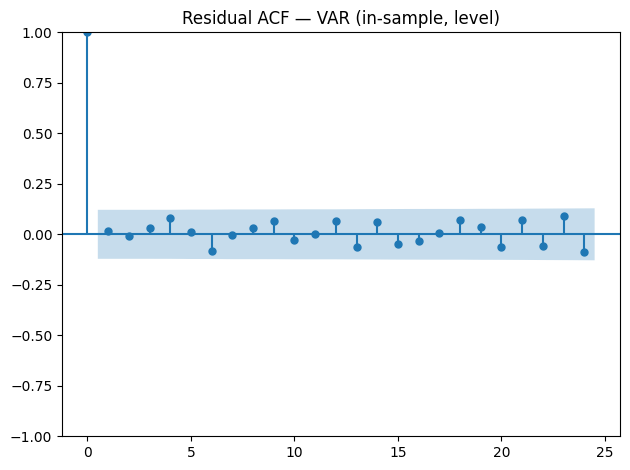

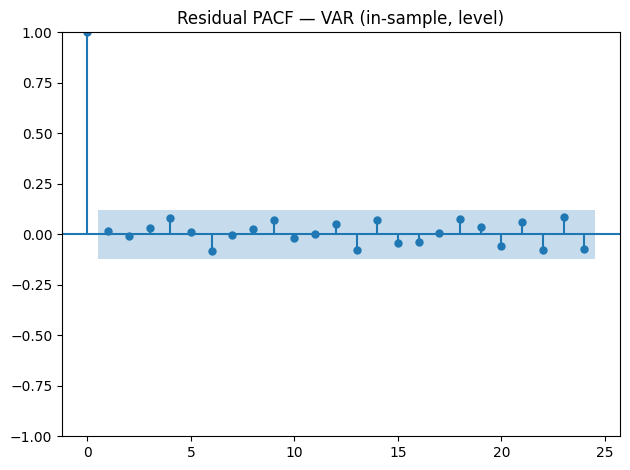


VAR(p=2) (in-sample, level)
------------------------------
Mean:   -0.000000
Std:    0.524256
Min:    -2.650368
Max:    1.824530

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
1     2.624006  1.052584e-01
2     5.827498  5.427188e-02
3    41.836998  4.344737e-09
12  131.740019  2.760540e-22
24  157.587335  1.273185e-21
48  276.398686  7.555271e-34


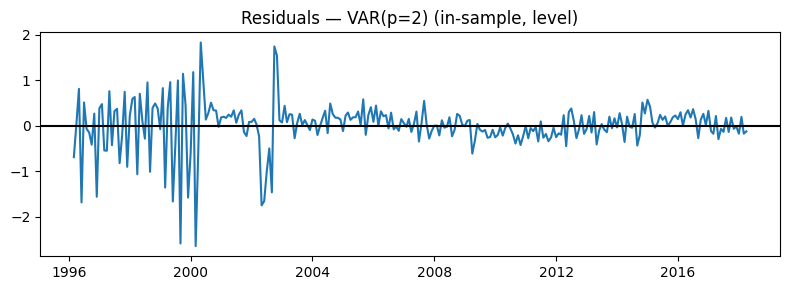

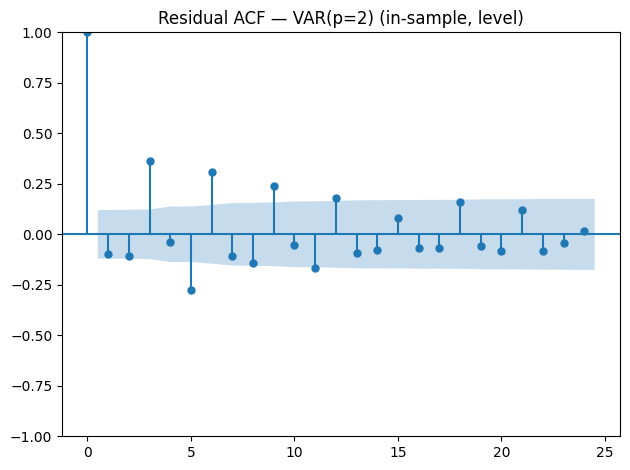

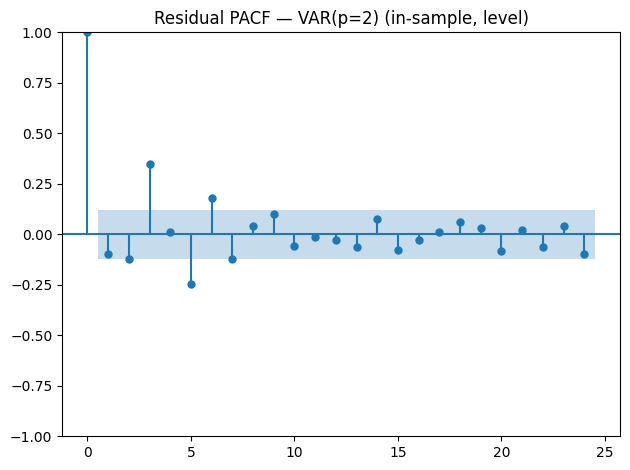


Random Forest (in-sample, level)
------------------------------
Mean:   0.000777
Std:    0.236861
Min:    -0.853294
Max:    0.761728

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
1     1.841803  1.747397e-01
2     3.476611  1.758181e-01
3     4.945767  1.758117e-01
12   53.217136  3.768652e-07
24   68.448204  3.747069e-06
48  105.205153  3.674375e-06


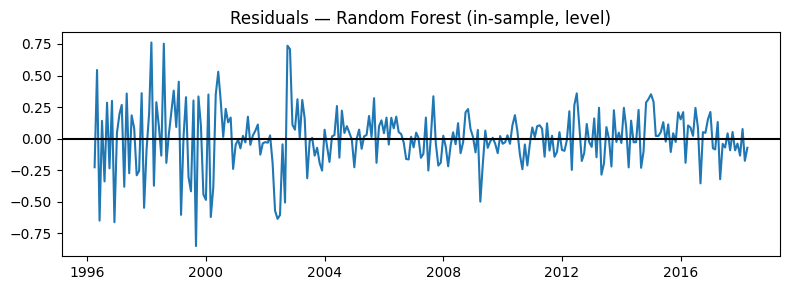

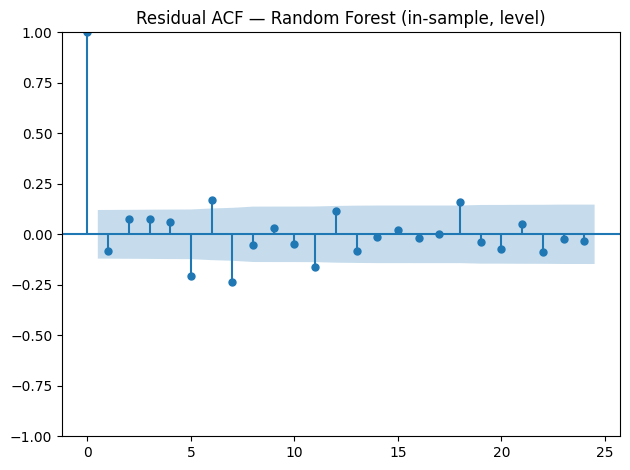

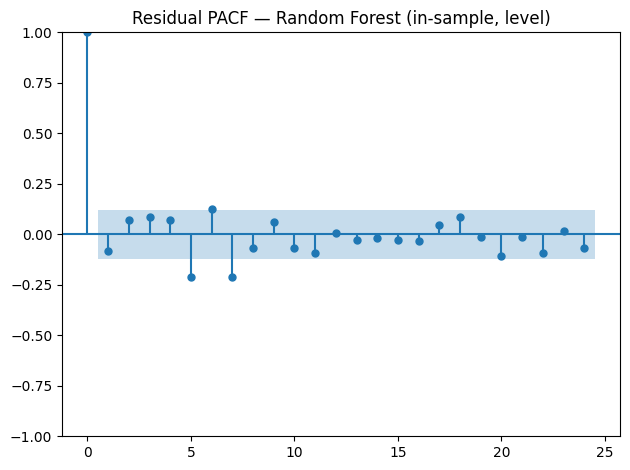

In [77]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def quick_resid_diagnostics(resid: pd.Series, title: str):
    print(f"\n{title}")
    print("------------------------------")
    print(f"Mean:   {resid.mean():.6f}")
    print(f"Std:    {resid.std():.6f}")
    print(f"Min:    {resid.min():.6f}")
    print(f"Max:    {resid.max():.6f}")

    # Ljung–Box test
    lb = acorr_ljungbox(resid.dropna(), lags=[1, 2, 3, 12, 24, 48], return_df=True)
    print("\nLjung–Box test (H0: no autocorrelation)")
    print(lb)

    plt.figure(figsize=(8,3))
    plt.plot(resid)
    plt.axhline(0, color="black")
    plt.title(f"Residuals — {title}")
    plt.tight_layout()
    plt.show()

    plot_acf(resid.dropna(), lags=24)
    plt.title(f"Residual ACF — {title}")
    plt.tight_layout()
    plt.show()

    plot_pacf(resid.dropna(), lags=24, method="ywm")
    plt.title(f"Residual PACF — {title}")
    plt.tight_layout()
    plt.show()


# Esempi:
quick_resid_diagnostics(rw_resid_in,          "Random Walk with Drift (in-sample, level)")
quick_resid_diagnostics(arima_201_resid_in,  f"Best ARIMA{best_order} (in-sample, level)")
quick_resid_diagnostics(arima_201_resid_in, "ARIMA(2, 0, 1) (in-sample, level)")
quick_resid_diagnostics(var_resid_in,         "VAR (in-sample, level)")
quick_resid_diagnostics(var_p2_resid_in,      "VAR(p=2) (in-sample, level)")
quick_resid_diagnostics(rf_resid_in,          "Random Forest (in-sample, level)")

### Confront the forecasts

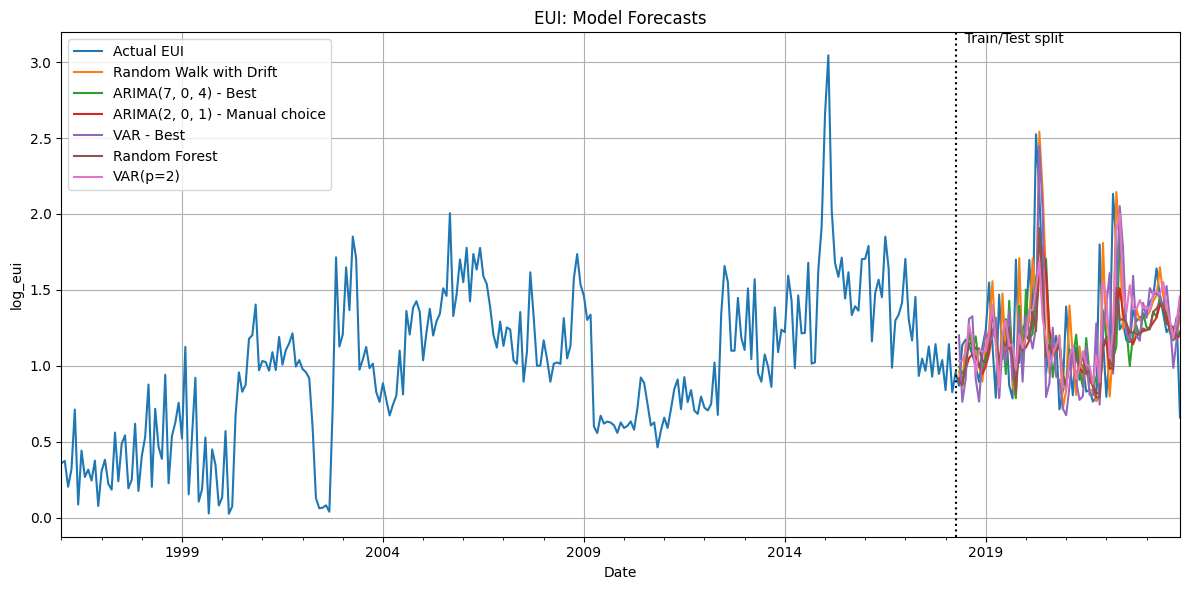

In [72]:
# -----------------------------
# 1. True series (levels)
# -----------------------------
y_train_log = train_df[target_col]
y_test_log  = test_df[target_col]


# -----------------------------
# 2. Build a combined DataFrame including VAR
# -----------------------------
plot_df = pd.DataFrame({
    "train_true": np.exp(y_train_log),
    "test_true":  np.exp(y_test_log),
    "rw":         np.exp(rw_fcast),
    "arima_best": np.exp(arima_best_forecast),
    "arima_201":  np.exp(arima_201_forecast),
    "rf":         np.exp(rf_fcast_series),
    "var_best":   np.exp(var_log_eui_forecast),
    "var_p2":     np.exp(var_p2_log_eui_forecast),
})


plot_df["actual"] = plot_df["train_true"].fillna(plot_df["test_true"])

# -----------------------------
# 3. Plot: train, test, forecasts
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

plot_df["actual"].plot(
    ax=ax,
    label="Actual EUI",
)

# Model forecasts on test period
plot_df["rw"].plot(
    ax=ax,
    label="Random Walk with Drift",
)
plot_df["arima_best"].plot(
    ax=ax,
    label=f"ARIMA{best_order} - Best",
)
plot_df["arima_201"].plot(
    ax=ax,
    label="ARIMA(2, 0, 1) - Manual choice",
)
plot_df["var_best"].plot(
    ax=ax,
    label="VAR - Best",
)
plot_df["rf"].plot(
    ax=ax,
    label="Random Forest",
)
plot_df["var_p2"].plot(
    ax=ax,
    label="VAR(p=2)",
)

# Vertical line at train/test split
split_date = train_df.index[-1]
ax.axvline(split_date, color="black", linestyle=":", linewidth=1.5)
ax.text(
    split_date,
    ax.get_ylim()[1],
    "  Train/Test split",
    va="top",
    ha="left",
)

ax.set_title("EUI: Model Forecasts")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


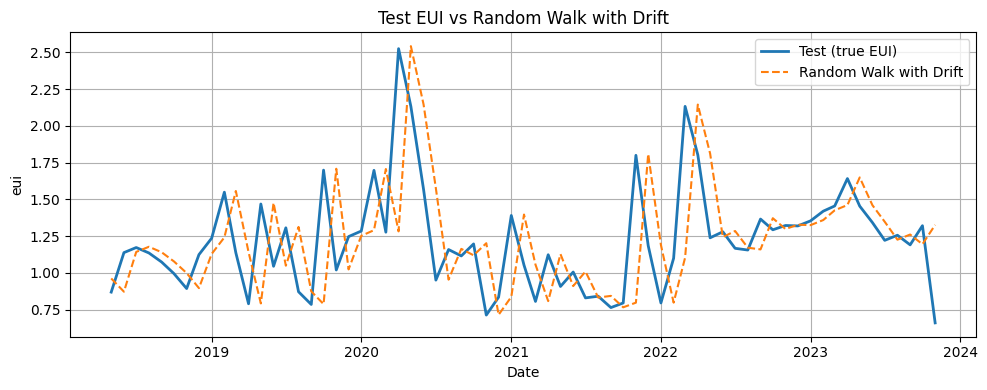

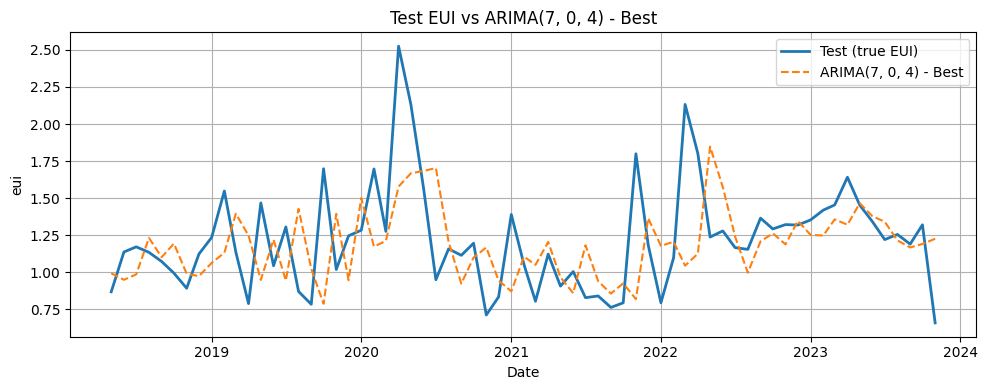

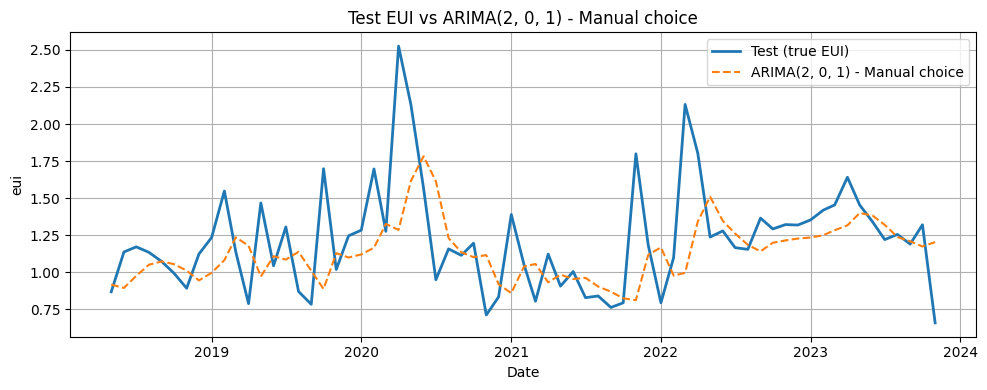

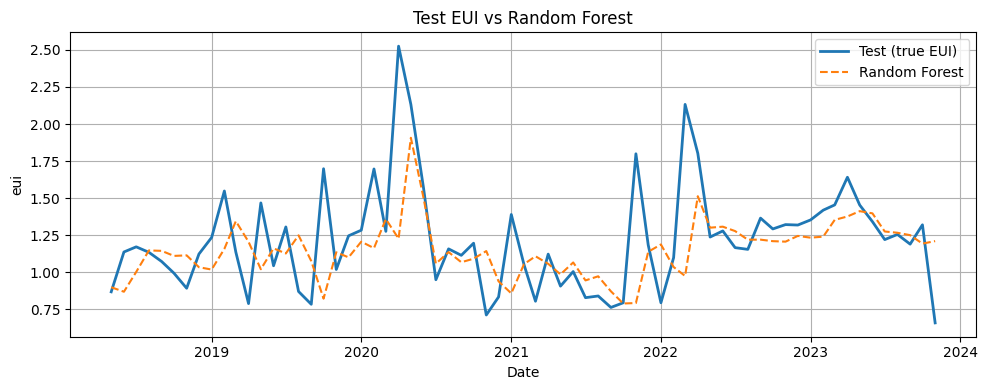

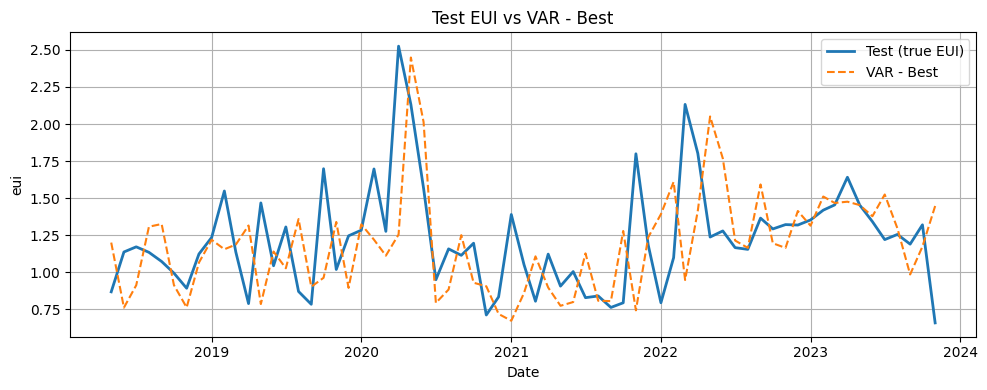

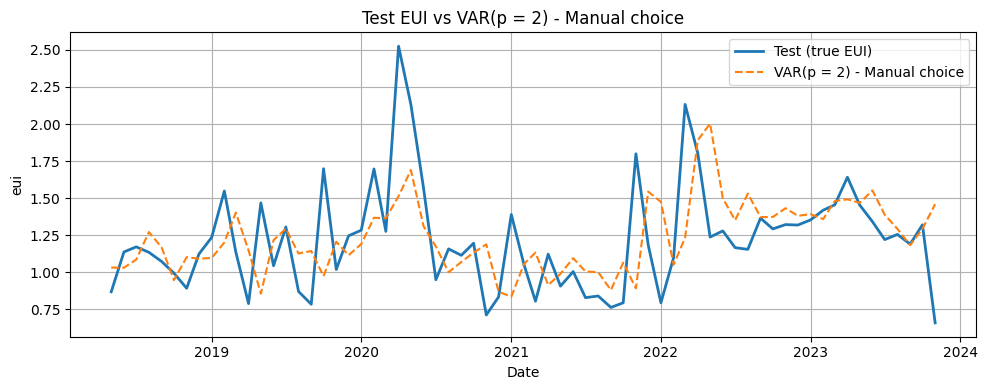

In [73]:
# ---------------------------------------------------
# Plots: true test EUI vs each model forecast (separately)
# ---------------------------------------------------

y_true_test = test_df["eui"]

forecast_dict = {
    "Random Walk with Drift": np.exp(rw_fcast).reindex(y_true_test.index),
    f"ARIMA{best_order} - Best": np.exp(arima_best_forecast).reindex(y_true_test.index),
    "ARIMA(2, 0, 1) - Manual choice": np.exp(arima_201_forecast).reindex(y_true_test.index),
    "Random Forest": np.exp(rf_fcast_series).reindex(y_true_test.index),
    "VAR - Best": np.exp(var_log_eui_forecast).reindex(y_true_test.index),
    "VAR(p = 2) - Manual choice": np.exp(var_p2_log_eui_forecast).reindex(y_true_test.index),
}

for model_name, y_hat in forecast_dict.items():
    # Drop any rows where either true or forecast is missing
    tmp = pd.concat([y_true_test, y_hat], axis=1, keys=["y_true", "y_hat"]).dropna()

    fig, ax = plt.subplots(figsize=(10, 4))

    # True values (test)
    ax.plot(
        tmp.index,
        tmp["y_true"],
        label="Test (true EUI)",
        linewidth=2,
    )

    # Model forecast
    ax.plot(
        tmp.index,
        tmp["y_hat"],
        label=f"{model_name}",
        linestyle="--",
    )

    ax.set_title(f"Test EUI vs {model_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("eui")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


### Evaluate the forecasts

In [74]:
# Metrics with EUI Levels
def compute_metrics(y_true, y_pred):
    """
    Returns a dictionary with MSFE, RMSFE, MAFE, MAPE.
    """
    err = y_true - y_pred
    abs_err = np.abs(err)

    metrics = {
        "MSFE": np.mean(err ** 2),
        "RMSFE": np.sqrt(np.mean(err ** 2)),
        "MAFE": np.mean(abs_err),
        "MAPE": np.mean(abs_err / np.abs(y_true)) * 100,
    }
    return metrics
# Align predictions with the true test values (levels)
y_true = test_df["eui"]

metrics_rw        = compute_metrics(y_true, np.exp(rw_fcast))
metrics_arimaBest = compute_metrics(y_true, np.exp(arima_best_forecast))
metrics_arima201  = compute_metrics(y_true, np.exp(arima_201_forecast))
metrics_rf        = compute_metrics(y_true, np.exp(rf_fcast_series))

# VAR (Best, from AIC) — uses var_log_eui_forecast from the "VAR - Best" section
metrics_var_best  = compute_metrics(y_true, np.exp(var_log_eui_forecast))

# VAR(p=2) — Manual choice — uses var_p2_log_eui_forecast from "VAR - Manual Choice"
metrics_var_p2    = compute_metrics(y_true, np.exp(var_p2_log_eui_forecast))

metrics_df = pd.DataFrame({
    "Random Walk with Drift":           metrics_rw,
    f"ARIMA{best_order} - Best":        metrics_arimaBest,
    "ARIMA(2, 0, 1) - Manual choice":   metrics_arima201,
    "Random Forest":                    metrics_rf,
    "VAR - Best (AIC)":                 metrics_var_best,
    "VAR(2) - Manual choice":           metrics_var_p2,
}).T

print("\n=== Forecast Accuracy Comparison ===")
print(metrics_df.round(4))



=== Forecast Accuracy Comparison ===
                                  MSFE   RMSFE    MAFE     MAPE
Random Walk with Drift          0.1551  0.3938  0.2828  23.2511
ARIMA(7, 0, 4) - Best           0.1365  0.3695  0.2702  22.3362
ARIMA(2, 0, 1) - Manual choice  0.1227  0.3503  0.2357  18.6258
Random Forest                   0.1147  0.3386  0.2160  17.3614
VAR - Best (AIC)                0.1646  0.4057  0.2948  24.5179
VAR(2) - Manual choice          0.1161  0.3407  0.2385  20.4677


### Consider ARIMA(2,0,1) as benchmark

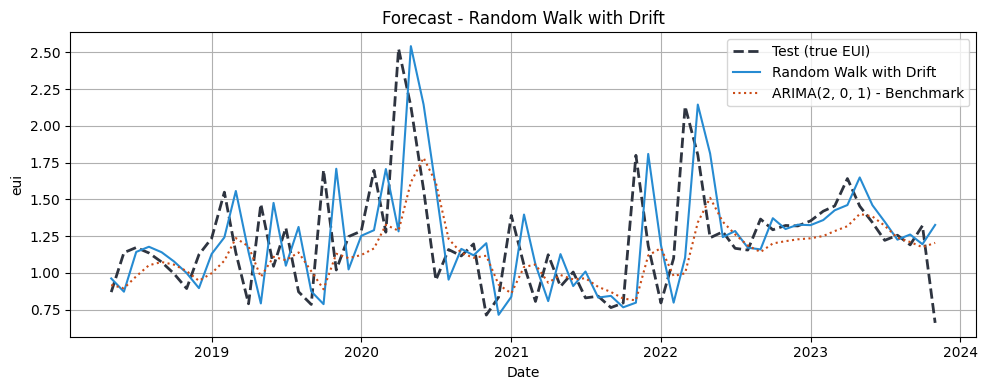

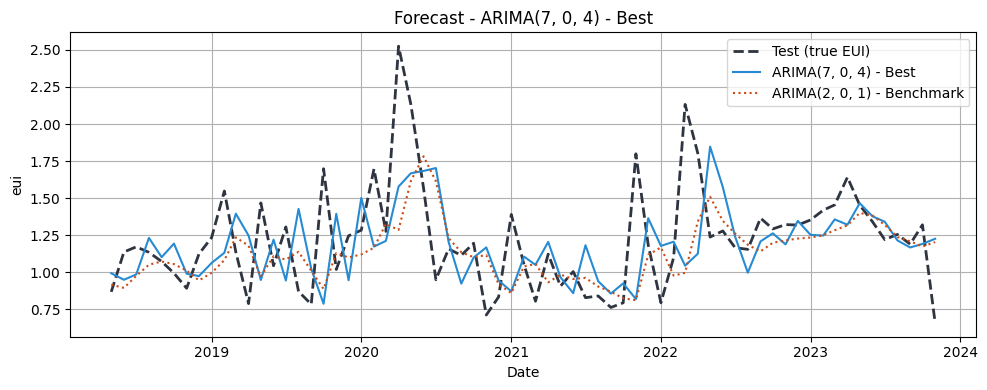

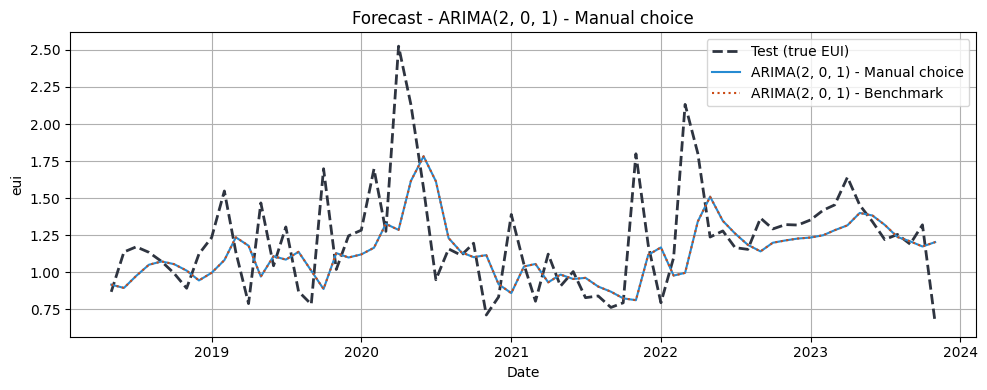

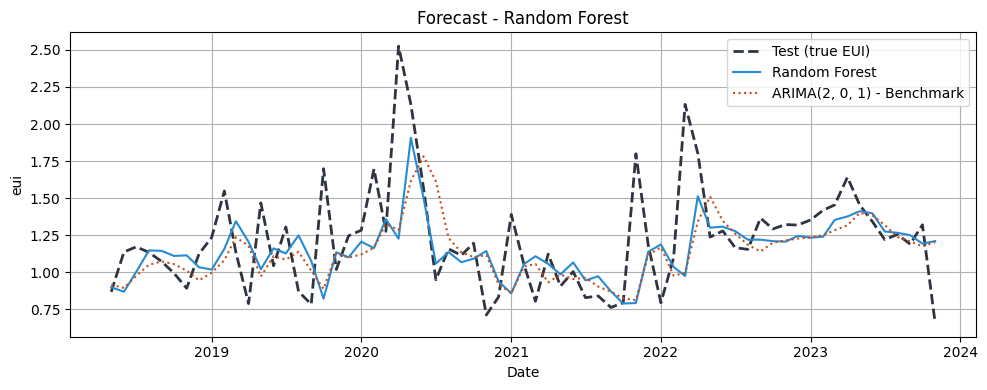

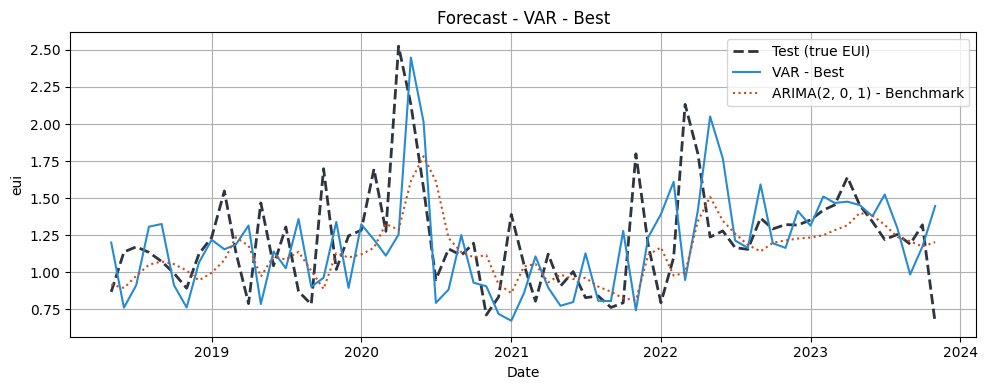

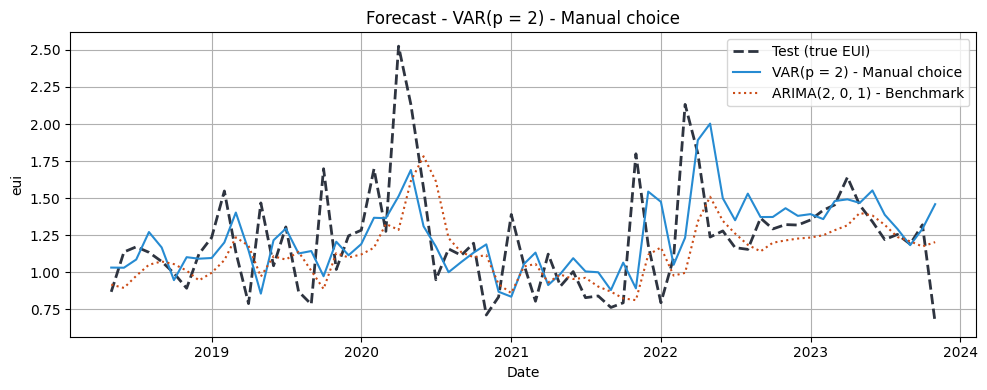

In [75]:
# ---------------------------------------------------
# Plots: true test EUI vs each model forecast (with ARIMA(2,1,0) as benchmark)
# ---------------------------------------------------

y_true_test = test_df["eui"]

# Benchmark: ARIMA(2, 0, 1) — in levels
arima_201_benchmark = np.exp(arima_201_forecast).reindex(y_true_test.index)

# Other model forecasts (levels) to be compared against the benchmark
forecast_dict = {
    "Random Walk with Drift": np.exp(rw_fcast).reindex(y_true_test.index),
    f"ARIMA{best_order} - Best": np.exp(arima_best_forecast).reindex(y_true_test.index),
    "ARIMA(2, 0, 1) - Manual choice": np.exp(arima_201_forecast).reindex(y_true_test.index),
    "Random Forest": np.exp(rf_fcast_series).reindex(y_true_test.index),
    "VAR - Best": np.exp(var_log_eui_forecast).reindex(y_true_test.index),
    "VAR(p = 2) - Manual choice": np.exp(var_p2_log_eui_forecast).reindex(y_true_test.index),
}

# Colors
COL_TRUE   = "#2E3440"  # dark grey/blue
COL_MODEL  = "#268BD2"  # blue
COL_BENCH  = "#CB4B16"  # orange (ARIMA(2,1,0) benchmark)

for model_name, y_hat in forecast_dict.items():

    # Drop missing
    tmp = pd.concat(
        [y_true_test, y_hat, arima_201_benchmark],
        axis=1,
        keys=["y_true", "y_hat", "bench"]
    ).dropna()

    fig, ax = plt.subplots(figsize=(10, 4))

    # True test series
    ax.plot(
        tmp.index,
        tmp["y_true"],
        label="Test (true EUI)",
        linewidth=2,
        linestyle="--",
        color=COL_TRUE,
    )

    # Model forecast
    ax.plot(
        tmp.index,
        tmp["y_hat"],
        label=model_name,
        color=COL_MODEL,
    )

    # ARIMA(2,1,0) benchmark
    ax.plot(
        tmp.index,
        tmp["bench"],
        label="ARIMA(2, 0, 1) - Benchmark",
        linestyle=":",
        color=COL_BENCH,
    )

    ax.set_title(f"Forecast - {model_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("eui")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


In [76]:
# Benchmark metrics
benchmark = metrics_arima201

# Create the ratio table
ratio_df = metrics_df.div(pd.Series(benchmark), axis=1)

print("\n=== Relative Performance Ratios (model metric / RW metric) ===")
print(ratio_df.round(4))


=== Relative Performance Ratios (model metric / RW metric) ===
                                  MSFE   RMSFE    MAFE    MAPE
Random Walk with Drift          1.2635  1.1240  1.1996  1.2483
ARIMA(7, 0, 4) - Best           1.1122  1.0546  1.1460  1.1992
ARIMA(2, 0, 1) - Manual choice  1.0000  1.0000  1.0000  1.0000
Random Forest                   0.9342  0.9666  0.9164  0.9321
VAR - Best (AIC)                1.3412  1.1581  1.2506  1.3163
VAR(2) - Manual choice          0.9459  0.9726  1.0118  1.0989
